# SPH Evaluation Kernels

This tutorial shows how to use the SPH (Smoothed Particle Hydrodynamics) evaluation machinery in Struphy to reconstruct a smooth field from particle data, and to verify correctness by comparing against known exact solutions.

The core idea: given $N$ particles with positions $\boldsymbol{\eta}_j \in [0,1]^3$ and scalar weights $\rho_j$, the SPH estimate of $\rho$ at an arbitrary point $\boldsymbol{\eta}$ is

$$
\rho(\boldsymbol{\eta}) \approx \sum_{j=0}^{N-1} \rho_j\, W_h(\boldsymbol{\eta} - \boldsymbol{\eta}_j)\,,
$$

where $W_h$ is a smoothing kernel with bandwidth $h$. The gradient can be evaluated by differentiating the kernel:

$$
\frac{\partial \rho}{\partial \eta_k}(\boldsymbol{\eta}) \approx \sum_{j=0}^{N-1} \rho_j\,
\frac{\partial W_h}{\partial \eta_k}(\boldsymbol{\eta} - \boldsymbol{\eta}_j)\,.
$$

**What this tutorial covers**

1. 1-D density reconstruction — value and first derivative, periodic and non-periodic boundary conditions, three kernel families.
2. 2-D density reconstruction — the same workflow on a meshgrid, with a colour-plot comparison against the exact field.

The evaluation is triggered via `ParticlesSPH.eval_density`, which internally dispatches to the box-based kernel in `struphy.pic.sph_eval_kernels` (an $\mathcal{O}(1)$-per-point algorithm that restricts the kernel sum to the 27 neighbouring sorting boxes).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from struphy import (
    BoundaryParameters,
    LoadingParameters,
    SortingParameters,
    domains,
    perturbations,
)
from struphy.fields_background.equils import ConstantVelocity
from struphy.pic.particles import ParticlesSPH

## Part 1 — 1-D density reconstruction

### Problem setup

We want to reconstruct the density field

$$
\rho(\eta_1) = 1.5 + \cos(2\pi\eta_1), \qquad \eta_1 \in [0, 1]\,,
$$

from $N$ particles whose weights $\rho_j$ are set by this exact function.

The domain is a 3-D cuboid — the $\eta_2, \eta_3$ directions are kept trivial (`l2=r2`, `l3=r3` effectively, all action is in $\eta_1$).  We use a **tesselation** loading strategy (particles placed on a regular lattice) so the reconstruction error is controlled by the lattice spacing rather than Monte Carlo noise.

In [2]:
# Cuboid domain: non-unit physical size, but the SPH evaluation is in logical space [0,1]^3
domain_1d = domains.Cuboid(l1=1.0, r1=2.0, l2=10.0, r2=20.0, l3=100.0, r3=200.0)

# Background equilibrium: constant density n0 = 1.5
background_1d = ConstantVelocity(n=1.5, density_profile="constant")
background_1d.domain = domain_1d

# Density perturbation: rho = n0 + cos(2 pi eta1)
pert_1d = {"n": perturbations.ModesCos(ls=(1,), amps=(1.0,))}

# Exact field and its eta1-derivative
rho_exact   = lambda e1, e2, e3: 1.5 + np.cos(2 * np.pi * e1)
drho_exact  = lambda e1, e2, e3: -2 * np.pi * np.sin(2 * np.pi * e1)

# Sorting: 24 boxes in eta1, 1 in eta2 / eta3 — purely 1-D
boxes_per_dim = (24, 1, 1)
sorting_params = SortingParameters(boxes_per_dim=boxes_per_dim)

# Kernel bandwidth = one box width in each dimension
h1 = 1 / boxes_per_dim[0]
h2 = 1 / boxes_per_dim[1]
h3 = 1 / boxes_per_dim[2]

# Evaluation grid (purely 1-D meshgrid)
n_eval = 200
eta1_pts = np.linspace(0, 1, n_eval)
eta2_pts = np.array([0.0])
eta3_pts = np.array([0.0])
ee1, ee2, ee3 = np.meshgrid(eta1_pts, eta2_pts, eta3_pts, indexing="ij")

print(f"Domain logical size: [0,1]^3   |   Sorting: {boxes_per_dim}")
print(f"Kernel bandwidth h1={h1:.4f}, h2={h2:.4f}, h3={h3:.4f}")

Domain logical size: [0,1]^3   |   Sorting: (24, 1, 1)
Kernel bandwidth h1=0.0417, h2=1.0000, h3=1.0000


### 1.1 Periodic boundary condition

With a periodic BC the boundary layer receives contributions from particles on the opposite side of the domain. The mirror images are handled automatically inside the distance kernel.

In [3]:
def make_particles_1d(bc_x, ppb=4, loading="tesselation"):
    """Construct and initialise a 1-D ParticlesSPH object."""
    loading_params  = LoadingParameters(ppb=ppb, seed=1607, loading=loading)
    boundary_params = BoundaryParameters(bc_sph=(bc_x, "periodic", "periodic"))
    particles = ParticlesSPH(
        comm_world=None,
        loading_params=loading_params,
        boundary_params=boundary_params,
        sorting_params=sorting_params,
        bufsize=1.0,
        domain=domain_1d,
        background=background_1d,
        perturbations=pert_1d,
        n_as_volume_form=True,
    )
    particles.draw_markers(sort=False)
    particles.initialize_weights()
    return particles

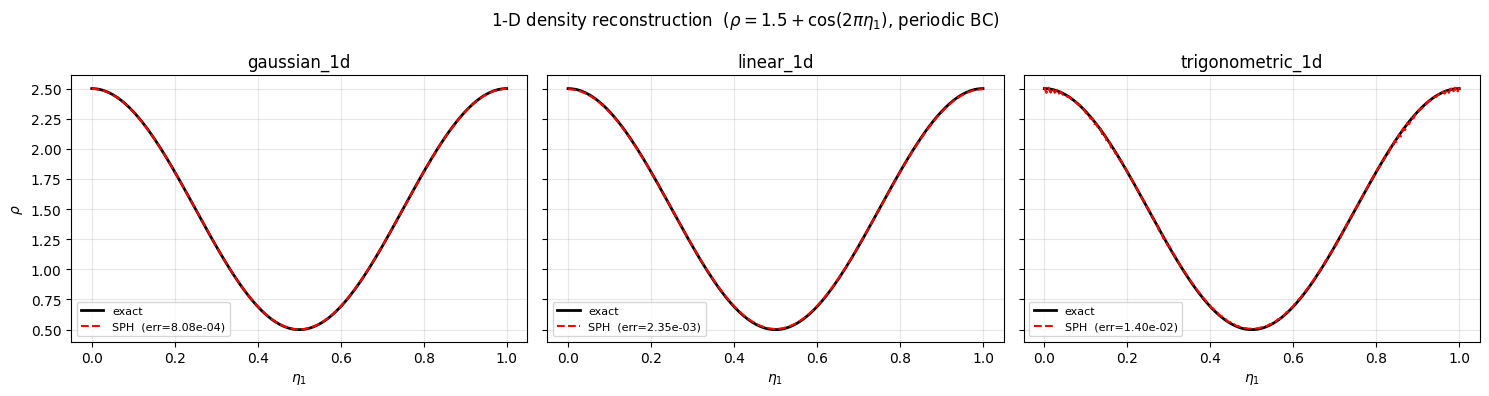

In [4]:
particles_periodic = make_particles_1d(ppb=4, bc_x="periodic")

kernels_1d = ["gaussian_1d", "linear_1d", "trigonometric_1d"]
x_plot = ee1.squeeze()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(r"1-D density reconstruction  ($\rho = 1.5 + \cos(2\pi\eta_1)$, periodic BC)")

for ax, kernel in zip(axes, kernels_1d):
    rho_sph = particles_periodic.eval_density(
        ee1, ee2, ee3,
        h1=h1, h2=h2, h3=h3,
        kernel_type=kernel,
        derivative=0,
    ).squeeze()
    rho_ex = rho_exact(x_plot, 0.0, 0.0)
    err = np.max(np.abs(rho_sph - rho_ex)) / np.max(np.abs(rho_ex))

    ax.plot(x_plot, rho_ex, "k-",  lw=2, label="exact")
    ax.plot(x_plot, rho_sph, "r--", lw=1.5, label=f"SPH  (err={err:.2e})")
    ax.set_title(kernel)
    ax.set_xlabel(r"$\eta_1$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$\rho$")
plt.tight_layout()
plt.show()

### 1.2 Derivative evaluation

Setting `derivative=1` returns the $\partial/\partial\eta_1$ component of the gradient instead of the field value. The trigonometric kernel is exact for a single cosine mode; the linear kernel requires more particles per box to reach the same accuracy.

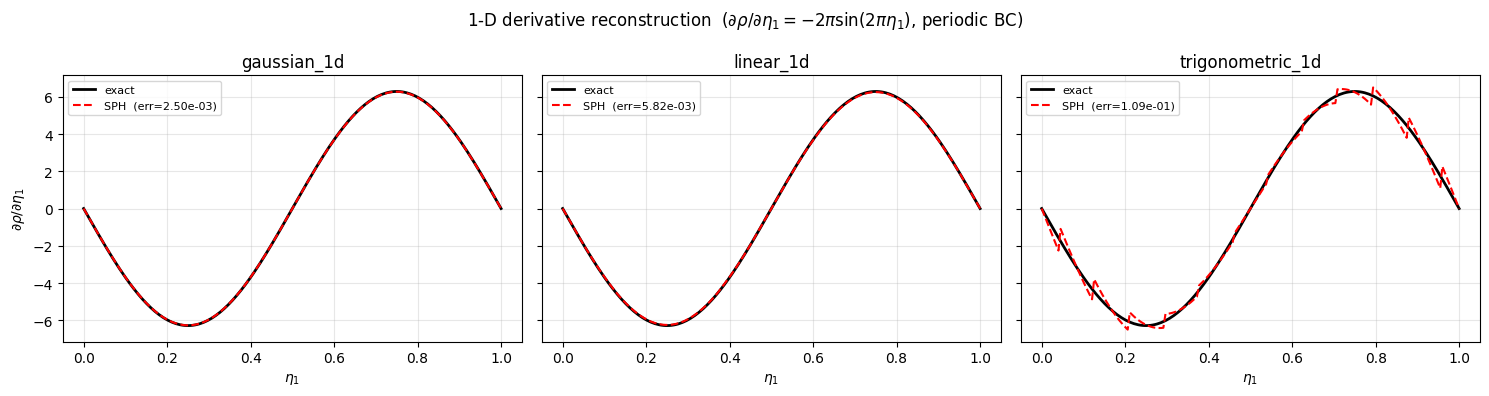

In [5]:
# More particles per box to resolve the derivative accurately
particles_deriv = make_particles_1d(bc_x="periodic", ppb=100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(
    r"1-D derivative reconstruction  ($\partial\rho/\partial\eta_1 = -2\pi\sin(2\pi\eta_1)$, periodic BC)"
)

for ax, kernel in zip(axes, kernels_1d):
    drho_sph = particles_deriv.eval_density(
        ee1, ee2, ee3,
        h1=h1, h2=h2, h3=h3,
        kernel_type=kernel,
        derivative=1,
    ).squeeze()
    drho_ex = drho_exact(x_plot, 0.0, 0.0)
    err = np.max(np.abs(drho_sph - drho_ex)) / np.max(np.abs(drho_ex))

    ax.plot(x_plot, drho_ex, "k-",  lw=2, label="exact")
    ax.plot(x_plot, drho_sph, "r--", lw=1.5, label=f"SPH  (err={err:.2e})")
    ax.set_title(kernel)
    ax.set_xlabel(r"$\eta_1$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$\partial\rho/\partial\eta_1$")
plt.tight_layout()
plt.show()

### 1.3 Effect of boundary conditions

Struphy supports three SPH boundary conditions:

| BC | Description |
|---|---|
| `"periodic"` | Mirror images placed across the periodic boundary. |
| `"mirror"` | Ghost particles reflected at the wall; enforces zero normal gradient. |
| `"fixed"` | Ghost particles reflected and negated; enforces zero field value at the wall. |

Below we compare all three for the density value.  Note that `mirror` and `fixed` are only meaningful near the boundary; the interior is identical to `periodic`.

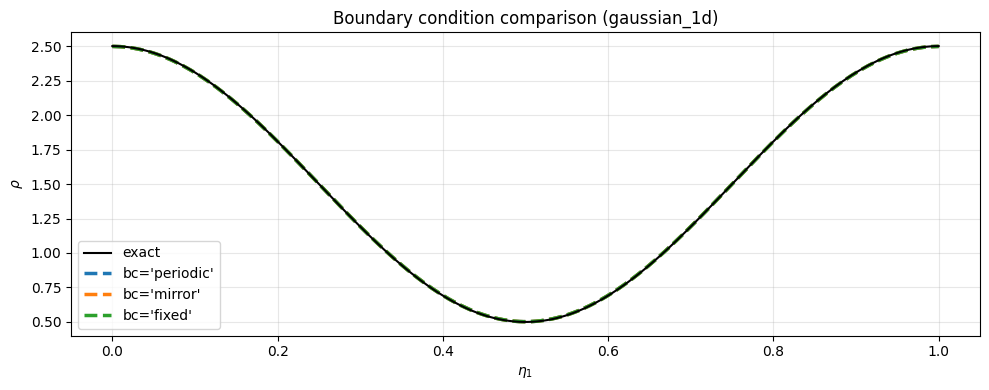

In [6]:
boundary_conditions = ["periodic", "mirror", "fixed"]
colors = ["tab:blue", "tab:orange", "tab:green"]
kernel = "gaussian_1d"

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, rho_exact(x_plot, 0.0, 0.0), "k-", lw=1.5, label="exact", zorder=5)

for bc, color in zip(boundary_conditions, colors):
    p = make_particles_1d(bc_x=bc)
    rho_sph = p.eval_density(
        ee1, ee2, ee3,
        h1=h1, h2=h2, h3=h3,
        kernel_type=kernel,
        derivative=0,
    ).squeeze()
    ax.plot(x_plot, rho_sph, "--", color=color, lw=2.5, label=f"bc={bc!r}")

ax.set_title(f"Boundary condition comparison ({kernel})")
ax.set_xlabel(r"$\eta_1$")
ax.set_ylabel(r"$\rho$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Tesselation vs Monte-Carlo loading

With **tesselation** loading, particles are placed on a regular lattice (`ppb` per sorting box), giving a smooth, deterministic reconstruction.  With **pseudo-random** loading (Monte Carlo), particle positions are drawn from a uniform distribution, which introduces sampling noise that decays only as $\mathcal{O}(N^{-1/2})$.

Here we compare both strategies at matched particle counts:

| Strategy | `ppb` | $N$ (approx.) |
|---|---|---|
| tesselation | 4 | 96 |
| pseudo_random | 40 | 960 |

The pseudo-random run uses **ten times** as many particles yet still shows visible fluctuations, illustrating why tesselation is preferred whenever the initial particle positions can be chosen freely.

Tesselation  ppb=4  →  Np=96
Pseudo-random  ppb=40  →  Np=960


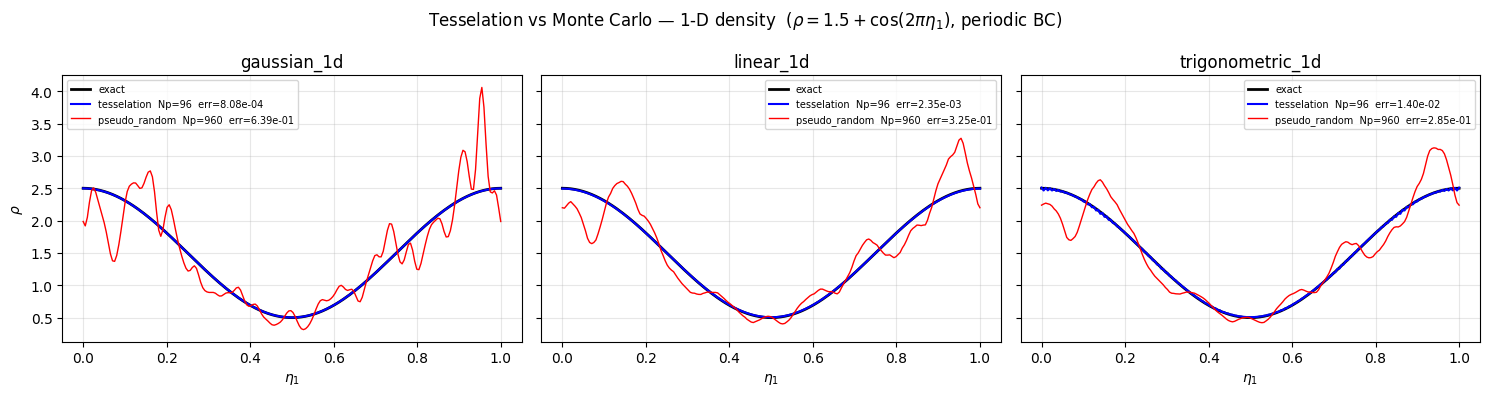

In [7]:
ppb_tess = 4
ppb_rand = ppb_tess * 10  # ten times more particles

particles_tess = make_particles_1d(bc_x="periodic", ppb=ppb_tess, loading="tesselation")
particles_rand = make_particles_1d(bc_x="periodic", ppb=ppb_rand, loading="pseudo_random")

Np_tess = particles_tess.Np
Np_rand = particles_rand.Np
print(f"Tesselation  ppb={ppb_tess}  →  Np={Np_tess}")
print(f"Pseudo-random  ppb={ppb_rand}  →  Np={Np_rand}")

rho_ex_1d = rho_exact(x_plot, 0.0, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(
    r"Tesselation vs Monte Carlo — 1-D density  ($\rho = 1.5 + \cos(2\pi\eta_1)$, periodic BC)"
)

for ax, kernel in zip(axes, kernels_1d):
    rho_tess = particles_tess.eval_density(
        ee1, ee2, ee3, h1=h1, h2=h2, h3=h3,
        kernel_type=kernel, derivative=0,
    ).squeeze()
    rho_rand = particles_rand.eval_density(
        ee1, ee2, ee3, h1=h1, h2=h2, h3=h3,
        kernel_type=kernel, derivative=0,
    ).squeeze()

    err_tess = np.max(np.abs(rho_tess - rho_ex_1d)) / np.max(np.abs(rho_ex_1d))
    err_rand = np.max(np.abs(rho_rand - rho_ex_1d)) / np.max(np.abs(rho_ex_1d))

    ax.plot(x_plot, rho_ex_1d, "k-", lw=2, label="exact")
    ax.plot(x_plot, rho_tess, "b-",  lw=1.5,
            label=f"tesselation  Np={Np_tess}  err={err_tess:.2e}")
    ax.plot(x_plot, rho_rand, "r-",  lw=1,
            label=f"pseudo_random  Np={Np_rand}  err={err_rand:.2e}")
    ax.set_title(kernel)
    ax.set_xlabel(r"$\eta_1$")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$\rho$")
plt.tight_layout()
plt.show()

## Part 2 — 2-D density reconstruction

### Problem setup

We extend the test to two dimensions and reconstruct

$$
\rho(\eta_1, \eta_2) = 1.5 + \cos(2\pi\eta_1)\cos(2\pi\eta_2)\,,
$$

together with its partial derivatives

$$
\frac{\partial\rho}{\partial\eta_1} = -2\pi\sin(2\pi\eta_1)\cos(2\pi\eta_2)\,,\qquad
\frac{\partial\rho}{\partial\eta_2} = -2\pi\cos(2\pi\eta_1)\sin(2\pi\eta_2)\,.
$$

The sorting uses a $12\times 12\times 1$ box grid, which matches the `trigonometric_2d`, `gaussian_2d`, and `linear_2d` kernel families.

In [8]:
domain_2d = domains.Cuboid(l1=1.0, r1=2.0, l2=0.0, r2=2.0, l3=100.0, r3=200.0)

background_2d = ConstantVelocity(n=1.5, density_profile="constant")
background_2d.domain = domain_2d

pert_2d = {"n": perturbations.ModesCosCos(ls=(1,), ms=(1,), amps=(1.0,))}

rho_2d_exact   = lambda e1, e2, e3: 1.5 + np.cos(2*np.pi*e1) * np.cos(2*np.pi*e2)
drho_2d_deta1  = lambda e1, e2, e3: -2*np.pi * np.sin(2*np.pi*e1) * np.cos(2*np.pi*e2)
drho_2d_deta2  = lambda e1, e2, e3: -2*np.pi * np.cos(2*np.pi*e1) * np.sin(2*np.pi*e2)

boxes_per_dim_2d = (12, 12, 1)
h1_2d = 1 / boxes_per_dim_2d[0]
h2_2d = 1 / boxes_per_dim_2d[1]
h3_2d = 1 / boxes_per_dim_2d[2]

# Tesselation loading: 16 particles per box
loading_params_2d  = LoadingParameters(ppb=16, loading="tesselation")
boundary_params_2d = BoundaryParameters(bc_sph=("periodic", "periodic", "periodic"))
sorting_params_2d  = SortingParameters(boxes_per_dim=boxes_per_dim_2d)

particles_2d = ParticlesSPH(
    comm_world=None,
    loading_params=loading_params_2d,
    boundary_params=boundary_params_2d,
    sorting_params=sorting_params_2d,
    bufsize=1.0,
    domain=domain_2d,
    background=background_2d,
    perturbations=pert_2d,
    n_as_volume_form=True,
)
particles_2d.draw_markers(sort=False)
particles_2d.initialize_weights()

# 2-D evaluation meshgrid
n_eval_2d = 50
eta1_2d = np.linspace(0, 1.0, n_eval_2d)
eta2_2d = np.linspace(0, 1.0, n_eval_2d)
eta3_2d = np.array([0.0])
ee1_2d, ee2_2d, ee3_2d = np.meshgrid(eta1_2d, eta2_2d, eta3_2d, indexing="ij")

print(f"Particles: {particles_2d.Np}   |   Boxes: {boxes_per_dim_2d}")

Particles: 2304   |   Boxes: (12, 12, 1)


### 2.1 Density value

We evaluate the density on the 2-D meshgrid and compare side-by-side with the exact field.

Max relative error: 6.115e-03


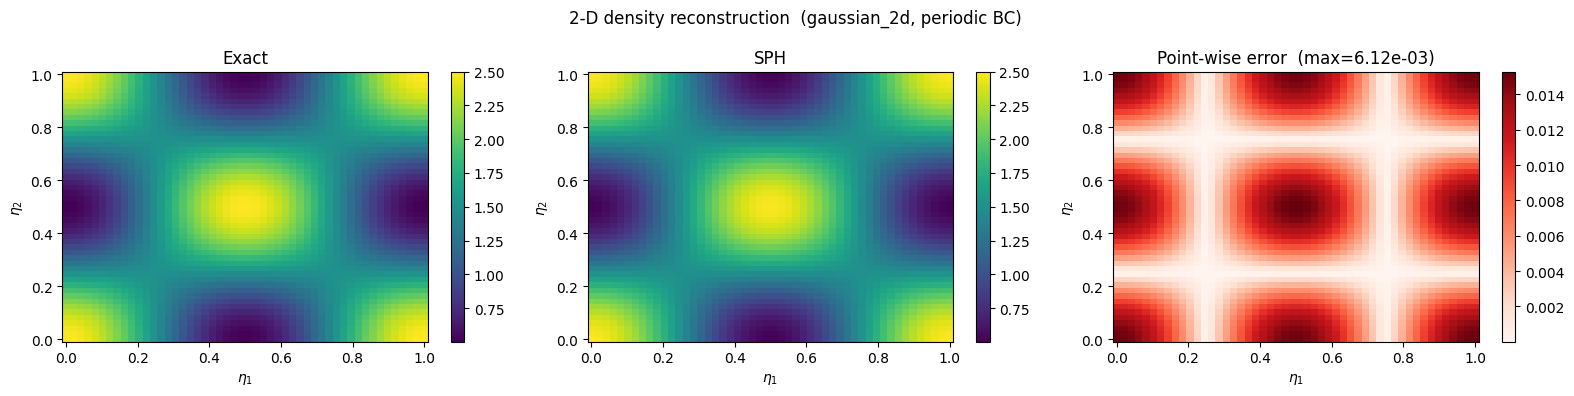

In [9]:
kernel_2d = "gaussian_2d"

rho_sph_2d = particles_2d.eval_density(
    ee1_2d, ee2_2d, ee3_2d,
    h1=h1_2d, h2=h2_2d, h3=h3_2d,
    kernel_type=kernel_2d,
    derivative=0,
).squeeze()

rho_ex_2d = rho_2d_exact(ee1_2d, ee2_2d, ee3_2d).squeeze()
err_2d = np.max(np.abs(rho_sph_2d - rho_ex_2d)) / np.max(np.abs(rho_ex_2d))
print(f"Max relative error: {err_2d:.3e}")

x_plot_2d = ee1_2d.squeeze()
y_plot_2d = ee2_2d.squeeze()
vmin = rho_ex_2d.min()
vmax = rho_ex_2d.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"2-D density reconstruction  ({kernel_2d}, periodic BC)")

im0 = axes[0].pcolormesh(x_plot_2d, y_plot_2d, rho_ex_2d, vmin=vmin, vmax=vmax, shading="auto")
axes[0].set_title("Exact")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(x_plot_2d, y_plot_2d, rho_sph_2d, vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title("SPH")
fig.colorbar(im1, ax=axes[1])

err_field = np.abs(rho_sph_2d - rho_ex_2d)
im2 = axes[2].pcolormesh(x_plot_2d, y_plot_2d, err_field, shading="auto", cmap="Reds")
axes[2].set_title(f"Point-wise error  (max={err_2d:.2e})")
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel(r"$\eta_1$")
    ax.set_ylabel(r"$\eta_2$")

plt.tight_layout()
plt.show()

### 2.2 Partial derivatives

`derivative=1` gives $\partial\rho/\partial\eta_1$ and `derivative=2` gives $\partial\rho/\partial\eta_2$.  We show both below using the trigonometric kernel, which is spectrally exact for smooth periodic functions.

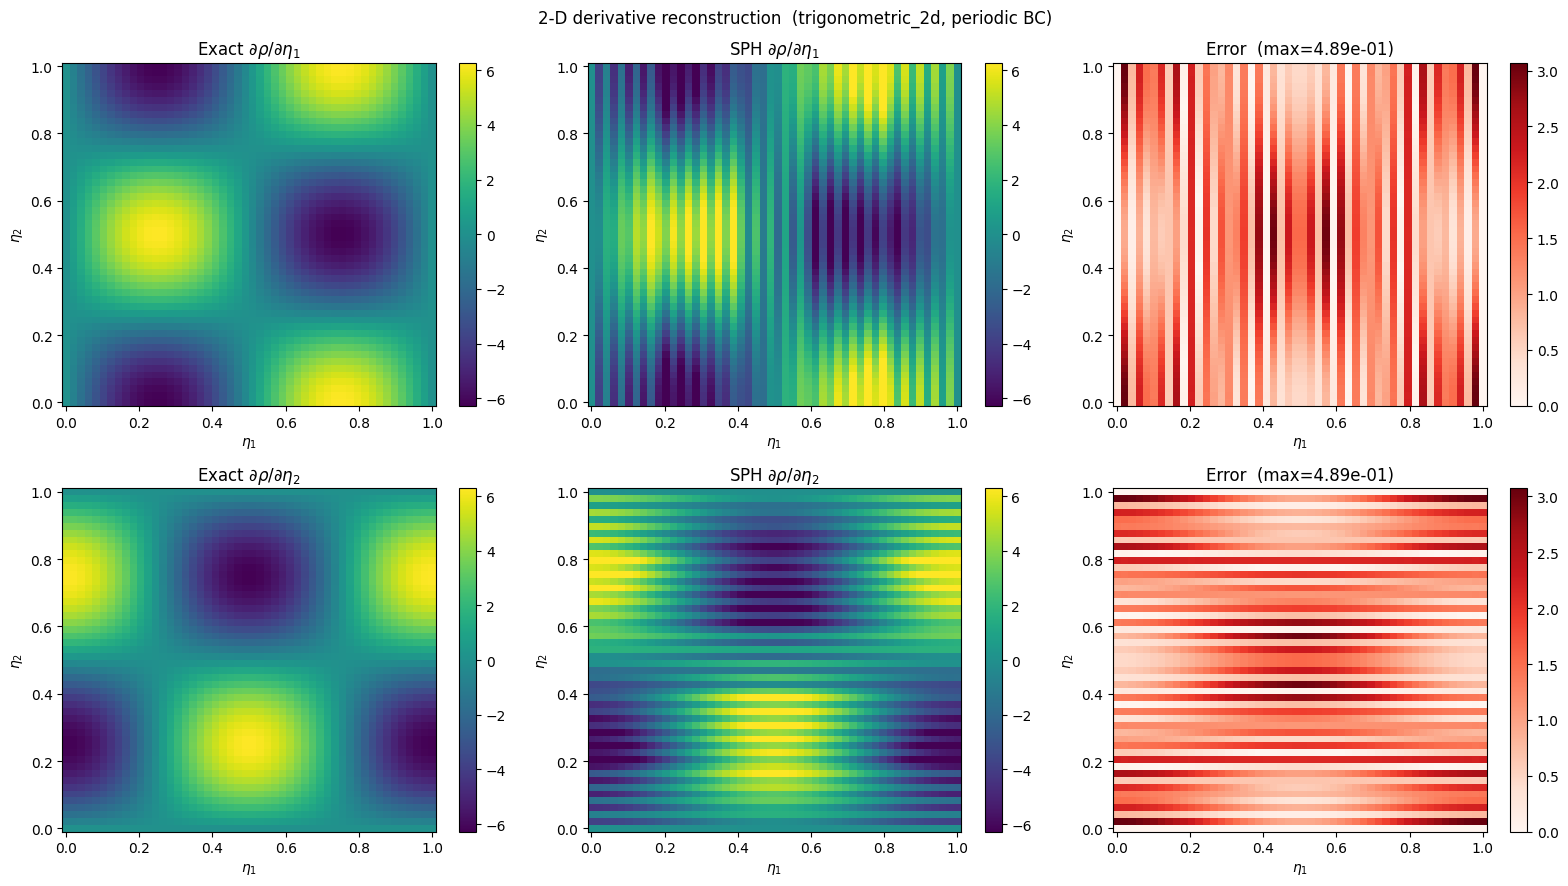

In [10]:
# More particles per box for the trigonometric kernel derivative test
loading_params_deriv = LoadingParameters(ppb=100, loading="tesselation")
particles_2d_deriv = ParticlesSPH(
    comm_world=None,
    loading_params=loading_params_deriv,
    boundary_params=boundary_params_2d,
    sorting_params=sorting_params_2d,
    bufsize=1.0,
    domain=domain_2d,
    background=background_2d,
    perturbations=pert_2d,
    n_as_volume_form=True,
)
particles_2d_deriv.draw_markers(sort=False)
particles_2d_deriv.initialize_weights()

kernel_deriv = "trigonometric_2d"
derivative_info = [
    (1, drho_2d_deta1, r"$\partial\rho/\partial\eta_1$"),
    (2, drho_2d_deta2, r"$\partial\rho/\partial\eta_2$"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"2-D derivative reconstruction  ({kernel_deriv}, periodic BC)")

for row, (deriv_idx, exact_fn, label) in enumerate(derivative_info):
    drho_sph = particles_2d_deriv.eval_density(
        ee1_2d, ee2_2d, ee3_2d,
        h1=h1_2d, h2=h2_2d, h3=h3_2d,
        kernel_type=kernel_deriv,
        derivative=deriv_idx,
    ).squeeze()
    drho_ex = exact_fn(ee1_2d, ee2_2d, ee3_2d).squeeze()
    err = np.max(np.abs(drho_sph - drho_ex)) / np.max(np.abs(drho_ex))

    vmin_d, vmax_d = drho_ex.min(), drho_ex.max()

    im0 = axes[row, 0].pcolormesh(x_plot_2d, y_plot_2d, drho_ex,  vmin=vmin_d, vmax=vmax_d, shading="auto")
    axes[row, 0].set_title(f"Exact {label}")
    fig.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].pcolormesh(x_plot_2d, y_plot_2d, drho_sph, vmin=vmin_d, vmax=vmax_d, shading="auto")
    axes[row, 1].set_title(f"SPH {label}")
    fig.colorbar(im1, ax=axes[row, 1])

    err_field = np.abs(drho_sph - drho_ex)
    im2 = axes[row, 2].pcolormesh(x_plot_2d, y_plot_2d, err_field, shading="auto", cmap="Reds")
    axes[row, 2].set_title(f"Error  (max={err:.2e})")
    fig.colorbar(im2, ax=axes[row, 2])

for ax in axes.flat:
    ax.set_xlabel(r"$\eta_1$")
    ax.set_ylabel(r"$\eta_2$")

plt.tight_layout()
plt.show()

### 2.3 Kernel comparison in 2-D

All three 2-D kernel families are compared for the density value.

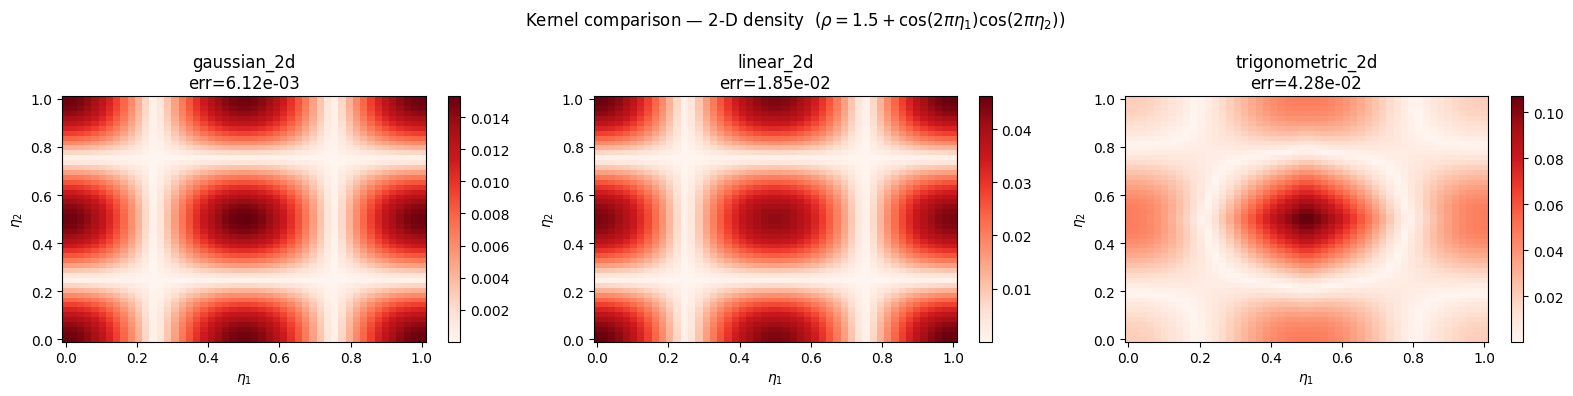

In [11]:
kernels_2d = ["gaussian_2d", "linear_2d", "trigonometric_2d"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(r"Kernel comparison — 2-D density  ($\rho = 1.5 + \cos(2\pi\eta_1)\cos(2\pi\eta_2)$)")

for ax, kernel in zip(axes, kernels_2d):
    rho_sph = particles_2d.eval_density(
        ee1_2d, ee2_2d, ee3_2d,
        h1=h1_2d, h2=h2_2d, h3=h3_2d,
        kernel_type=kernel,
        derivative=0,
    ).squeeze()
    rho_ex = rho_2d_exact(ee1_2d, ee2_2d, ee3_2d).squeeze()
    err = np.max(np.abs(rho_sph - rho_ex)) / np.max(np.abs(rho_ex))

    im = ax.pcolormesh(
        x_plot_2d, y_plot_2d, np.abs(rho_sph - rho_ex),
        shading="auto", cmap="Reds",
    )
    ax.set_title(f"{kernel}\nerr={err:.2e}")
    ax.set_xlabel(r"$\eta_1$")
    ax.set_ylabel(r"$\eta_2$")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Summary

| Task | Key parameter |
|---|---|
| Field value | `derivative=0` |
| $\partial/\partial\eta_1$ | `derivative=1` |
| $\partial/\partial\eta_2$ | `derivative=2` |
| $\partial/\partial\eta_3$ | `derivative=3` |
| Kernel family | `kernel_type` — e.g. `"gaussian_1d"`, `"trigonometric_2d"`, `"linear_3d"` |
| Kernel bandwidth | `h1`, `h2`, `h3` — typically set to `1/boxes_per_dim` |

The error decreases as `ppb` (particles per box) increases and as the kernel bandwidth matches the inter-particle spacing.  The **trigonometric** kernel achieves spectral accuracy for smooth periodic functions; the **Gaussian** and **linear** kernels are more robust near non-periodic boundaries.

For implementation details of the underlying kernel functions see `struphy.pic.sph_eval_kernels` and `struphy.pic.sph_smoothing_kernels`.